In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# PART 1: DATA CLEANING & UNDERSTANDING

In [3]:
# 1. Import dataset

In [4]:
df = pd.read_csv(r"C:\Users\PCS\Downloads\Task 2 - Business Analyst\Shopping Mall Customer Segmentation Data .csv")
df.head()

,Customer ID,Age,Gender,Annual Income,Spending Score
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76


In [5]:
df

,Customer ID,Age,Gender,Annual Income,Spending Score
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76
...,...,...,...,...,...
15074,a0504768-a85f-4930-ac24-55bc8e4fec9e,29,Female,97723,30
15075,a08c4e0e-d1fe-48e7-9366-aab11ae409cd,22,Male,73361,74
15076,0e87c25a-268c-401a-8ba1-7111dcde6f1a,18,Female,112337,48
15077,5f388cbe-3373-4e16-b743-38f508f2249f,26,Female,94312,5


In [6]:
# Shape

In [7]:
df.shape

(15079, 5)

In [8]:
# 2. Check for missing / null values

In [9]:
df.isnull().sum()

Customer ID       0
Age               0
Gender            0
Annual Income     0
Spending Score    0
dtype: int64

In [10]:
# 3. Check data types

In [11]:
df.dtypes

Customer ID       object
Age                int64
Gender            object
Annual Income      int64
Spending Score     int64
dtype: object

In [12]:
# Basic statistics

In [13]:
df.describe()

,Age,Annual Income,Spending Score
count,15079.000000,15079.000000,15079.000000
mean,54.191591,109742.880562,50.591617
std,21.119207,52249.425866,28.726977
min,18.000000,20022.000000,1.000000
25%,36.000000,64141.000000,26.000000
50%,54.000000,109190.000000,51.000000
75%,72.000000,155008.000000,75.000000
max,90.000000,199974.000000,100.000000


In [14]:
# Check for duplicates

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
# PART 2: CUSTOMER ANALYSIS

In [17]:
# Q1. Average age

In [18]:
avg_age = df['Age'].mean().round(2)

In [19]:
avg_age

np.float64(54.19)

In [20]:
# Average age = 54.19 

In [21]:
# Q2. Average annual income

In [22]:
avg_income = df['Annual Income'].mean().round(2)

In [23]:
avg_income

np.float64(109742.88)

In [24]:
#Note :  Average annual income = 109742.88

In [25]:
# Q3. Which gender spends more?

In [26]:
gender_spending = df.groupby('Gender')['Spending Score'].mean().round(2)

In [27]:
gender_spending

Gender
Female    50.40
Male      50.78
Name: Spending Score, dtype: float64

In [28]:
top_gender = gender_spending.idxmax()

In [29]:
top_gender

'Male'

In [30]:
#NOTE: The difference is very small — gender is NOT a strong predictor."

In [31]:
# Q4. Age group with highest spending score

In [32]:
df['Age_Group'] = pd.cut(df['Age'],
                          bins=[17, 25, 35, 45, 55, 65, 90],
                          labels=['18-25', '26-35', '36-45', '46-55', '56-65', '66+'])

In [33]:
age_spending = df.groupby('Age_Group', observed=True)['Spending Score'].mean().round(2)

In [34]:
age_spending

Age_Group
18-25    51.84
26-35    49.80
36-45    50.62
46-55    51.08
56-65    50.71
66+      50.27
Name: Spending Score, dtype: float64

In [35]:
best_age_group = age_spending.idxmax()

In [36]:
best_age_group

'18-25'

In [37]:
# Note: Age group with highest spending score is 18-25

In [38]:
# Q5. Relationship between annual income and spending score

In [39]:
corr = df['Annual Income'].corr(df['Spending Score'])

In [40]:
corr

np.float64(0.0032341193354843375)

In [41]:
# Note : Near-ZERO correlation. Higher income does NOT predict higher spending.
#  This means the mall attracts diverse spenders regardless of income level.

In [42]:
# PART 3: CUSTOMER SEGMENTATION

In [43]:
# Rule-based segmentation using median split 
#i am not choosing average here because Average gets affected by very rich/poor customers. Median is more fair and balanced.

In [44]:
income_median = df['Annual Income'].median()
spending_median = df['Spending Score'].median()

In [45]:
def assign_segment(row):
    high_income = row['Annual Income'] >= income_median
    high_spending = row['Spending Score'] >= spending_median
    if high_income and high_spending:
        return 'High Income - High Spending'
    elif high_income and not high_spending:
        return 'High Income - Low Spending'
    elif not high_income and high_spending:
        return 'Low Income - High Spending'
    else:
        return 'Low Income - Low Spending'

df['Segment'] = df.apply(assign_segment, axis=1)
df[['Age', 'Gender', 'Annual Income', 'Spending Score', 'Segment']].head()
seg_counts = df['Segment'].value_counts()


In [46]:
# count segment

In [47]:
seg_counts

Segment
High Income - High Spending    3827
Low Income - Low Spending      3798
Low Income - High Spending     3741
High Income - Low Spending     3713
Name: count, dtype: int64

In [48]:
# segment percentage

In [49]:
seg_percent = (seg_counts / len(df) * 100).round(2)

In [50]:
seg_percent

Segment
High Income - High Spending    25.38
Low Income - Low Spending      25.19
Low Income - High Spending     24.81
High Income - Low Spending     24.62
Name: count, dtype: float64

In [55]:
# PART 4: VISUALIZATIONS

In [56]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8 , 5)

In [57]:
#Chart 1 — Gender-wise Customer Distribution (Pie Chart)

In [58]:
# Count male and female customers
gender_counts = df['Gender'].value_counts()

In [59]:
gender_counts

Gender
Male      7595
Female    7484
Name: count, dtype: int64

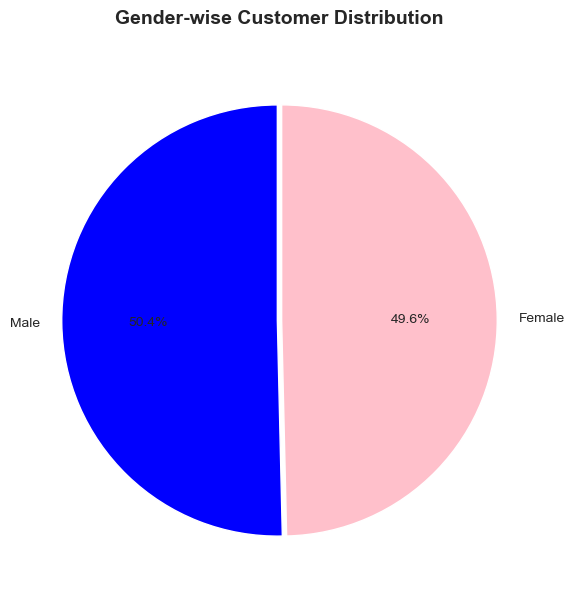

In [60]:
plt.figure(figsize=(7, 7))
plt.pie(gender_counts,labels=gender_counts.index,autopct='%1.1f%%', 
        colors= ['blue', 'pink'], startangle=90, explode=(0.01, 0.01)) 
plt.title('Gender-wise Customer Distribution',fontsize=14, fontweight='bold', pad=20)
plt.savefig('chart1_gender.png', dpi=150, bbox_inches='tight')
plt.show()

In [61]:
#Chart 2 — Age-wise Analysis (Histogram)

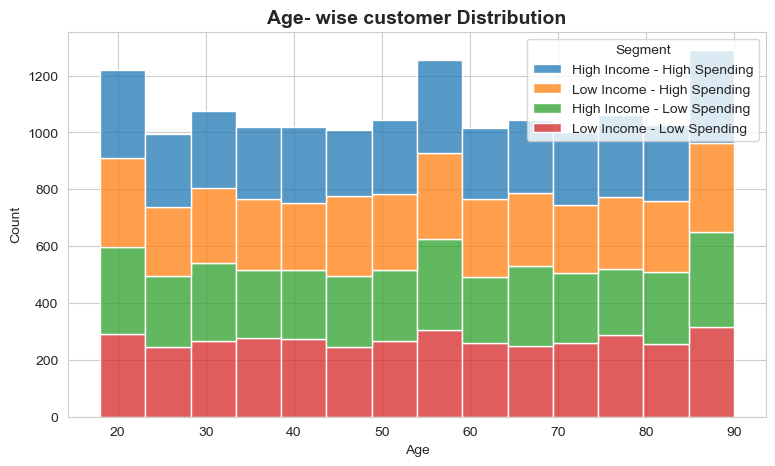

In [107]:
age_counts = df['Age_Group'].value_counts().sort_index()
plt.figure(figsize=(9, 5))
sns.histplot(data = df , x = 'Age', bins=10 , hue = 'Segment' , multiple = 'stack' , binwidth = 5)
plt.title("Age- wise customer Distribution" , fontweight = 'bold' , fontsize = 14)
plt.savefig('chart2_age.png', dpi=150, bbox_inches='tight')
plt.show()


In [79]:
#Chart 3 — Income vs Spending Scatter Plot

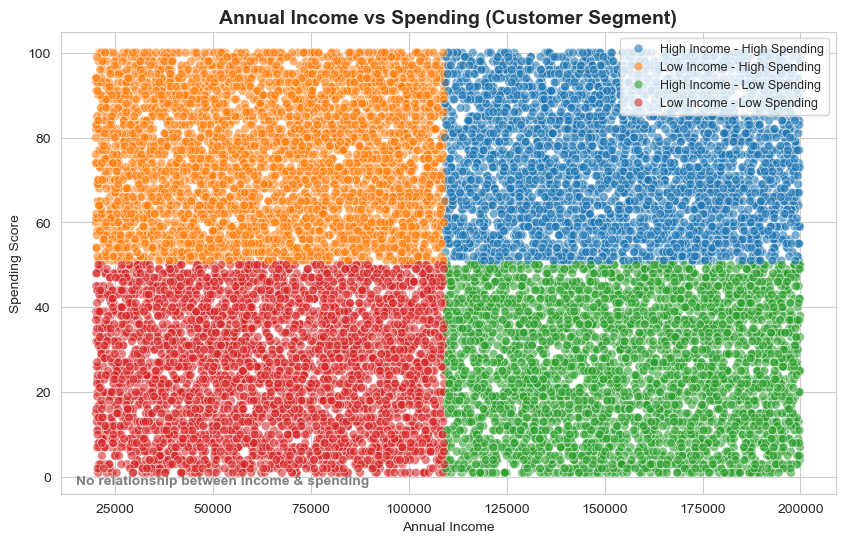

In [94]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Annual Income',
    y='Spending Score',
    hue='Segment',
    data=df,
    s=40,
    alpha=0.6
)

plt.title('Annual Income vs Spending (Customer Segment)', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=9)
plt.annotate('No relationship between income & spending', xy=(0.02, 0.02), xycoords='axes fraction', fontweight='bold', color='gray')
plt.savefig('chart3_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


In [65]:
#Chart 4 — Segment-wise Distribution (Bar Chart)

In [66]:
seg_counts = df['Segment'].value_counts()

In [67]:
seg_counts

Segment
High Income - High Spending    3827
Low Income - Low Spending      3798
Low Income - High Spending     3741
High Income - Low Spending     3713
Name: count, dtype: int64

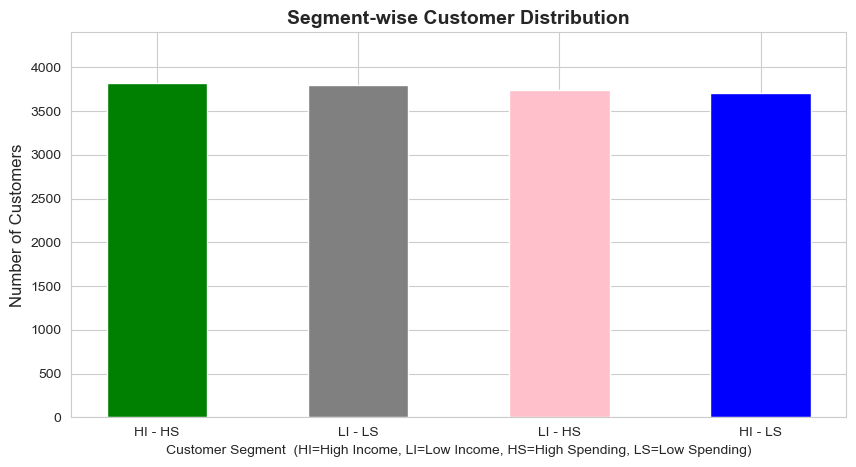

In [68]:
seg_counts = df['Segment'].value_counts()
short_labels = ['HI - HS', 'LI - LS', 'LI - HS', 'HI - LS']
bar_colors = ['green', 'gray', 'pink', 'blue']
plt.figure(figsize=(10, 5))

bars = plt.bar(short_labels, seg_counts.values, color=bar_colors, edgecolor='white', width=0.5)
plt.title('Segment-wise Customer Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Customer Segment  (HI=High Income, LI=Low Income, HS=High Spending, LS=Low Spending)', fontsize=10)
plt.ylabel('Number of Customers', fontsize=12)
plt.ylim(0, seg_counts.max() * 1.15)
plt.savefig('chart4_segments.png', dpi=150, bbox_inches='tight')
plt.show()

In [69]:
# Combine All 4 Charts in One Dashboard

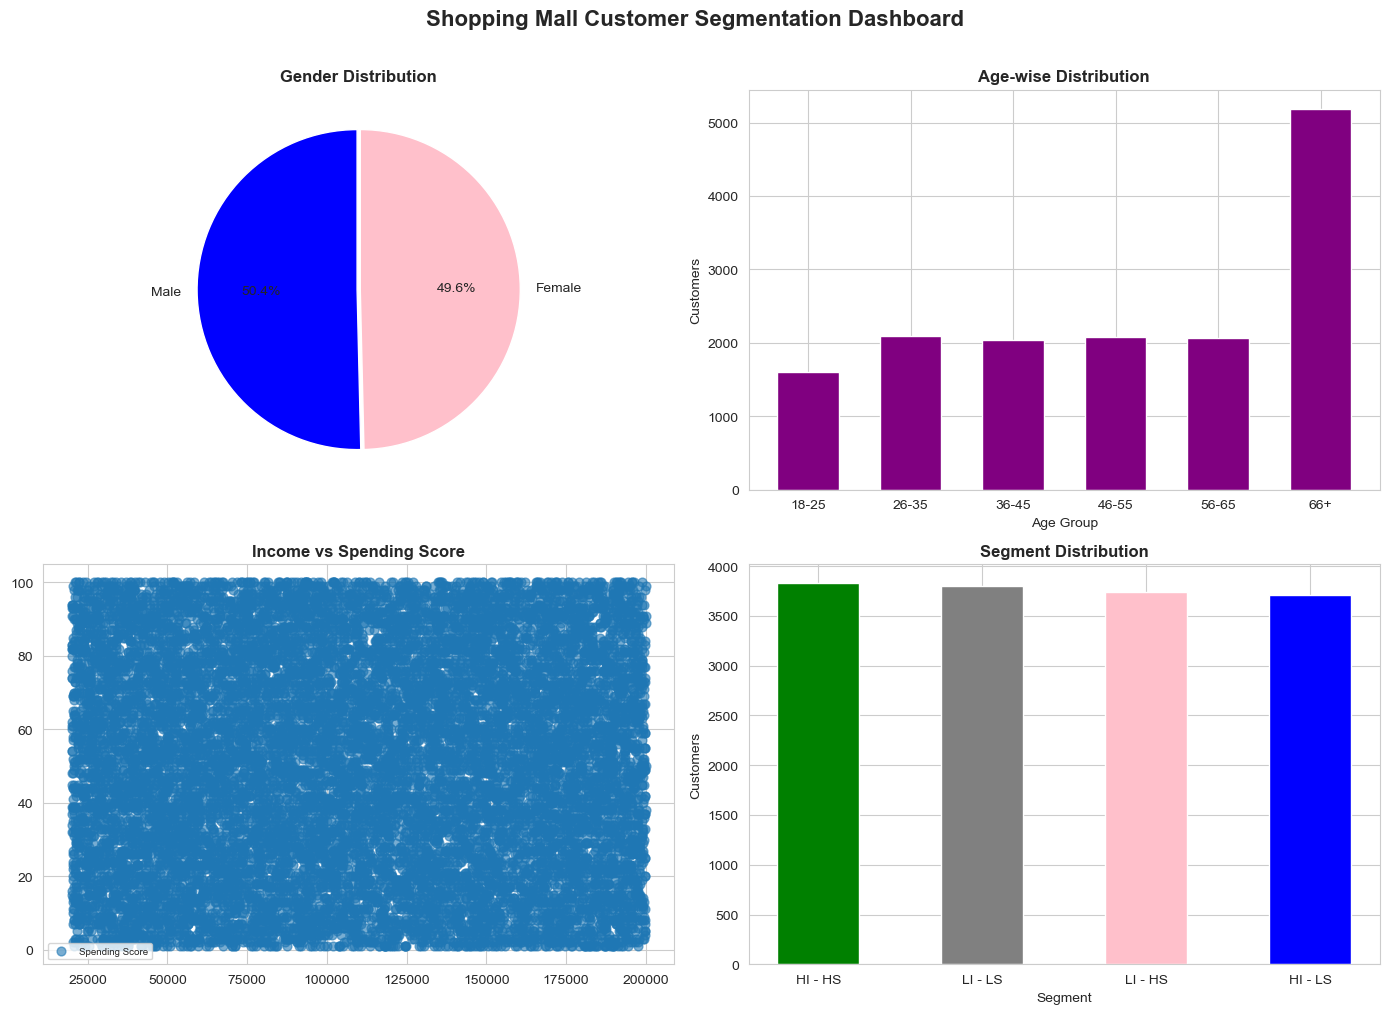

In [98]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Shopping Mall Customer Segmentation Dashboard', fontsize=16, fontweight='bold', y=1.01)

#Chart 1 — Gender-wise Customer Distribution (Pie Chart)
axes[0,0].pie(gender_counts,labels=gender_counts.index,autopct='%1.1f%%', 
        colors= ['blue', 'pink'], startangle=90, explode=(0.01, 0.01)) 
axes[0,0].set_title('Gender Distribution', fontweight='bold')

#Chart 2 — Age-wise Analysis (Bar Chart)

age_counts = df['Age_Group'].value_counts().sort_index()
bars = axes[0,1].bar(age_counts.index, age_counts.values, color= 'purple', edgecolor='white',width=0.6)
axes[0,1].set_title('Age-wise Distribution', fontweight='bold')
axes[0,1].set_xlabel('Age Group')
axes[0,1].set_ylabel('Customers')


#Chart 3 — Income vs Spending (Customer Segment) Scatter Plot

axes[1,0].scatter(
    x='Annual Income',
    y='Spending Score',
    data=df,
    s=40,
    alpha=0.6
)
axes[1,0].set_title('Income vs Spending Score', fontweight='bold')
axes[1,0].legend(fontsize=7)

#Chart 4 — Segment-wise Distribution (Bar Chart)

seg_counts = df['Segment'].value_counts()
short_labels = ['HI - HS', 'LI - LS', 'LI - HS', 'HI - LS']
bar_colors = ['green', 'gray', 'pink', 'blue']
bars = axes[1,1].bar(short_labels, seg_counts.values, color=bar_colors, edgecolor='white', width=0.5)
axes[1,1].set_title('Segment Distribution', fontweight='bold')
axes[1,1].set_xlabel('Segment')
axes[1,1].set_ylabel('Customers')

plt.tight_layout()
plt.savefig('my_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#Box Plot 1 — Spending Score by Segment

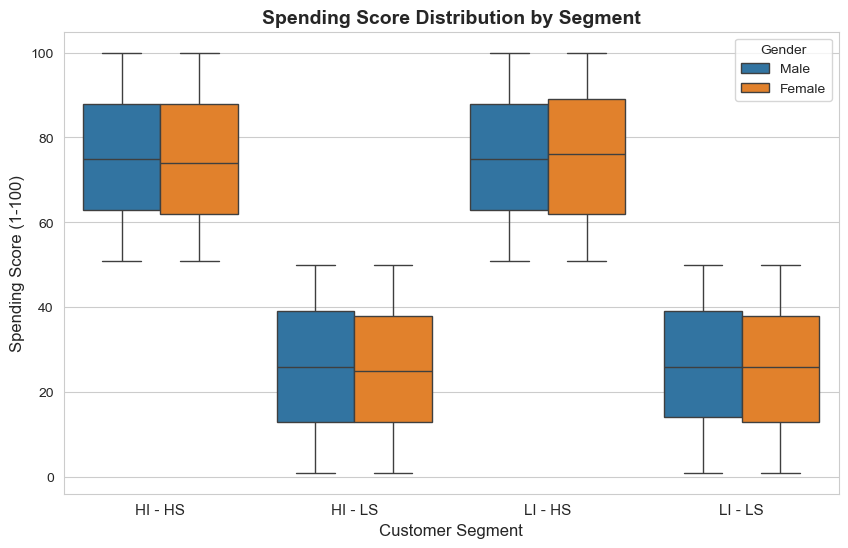

In [119]:
plt.figure(figsize=(10, 6))
segment_order = [
    'High Income - High Spending',
    'High Income - Low Spending',
    'Low Income - High Spending',
    'Low Income - Low Spending'
]
short_names = ['HI - HS', 'HI - LS', 'LI - HS', 'LI - LS']
sns.boxplot(data=df,
            x='Segment',
            y='Spending Score',
            hue = 'Gender',
            order=segment_order)
plt.xticks(ticks=[0, 1, 2, 3],
           labels=short_names,
           fontsize=11)

plt.title('Spending Score Distribution by Segment',
          fontsize=14, fontweight='bold')
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.savefig('boxplot2_income_by_segment.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [51]:
# Print full analysis summary
print("=" * 60)
print("   SHOPPING MALL CUSTOMER SEGMENTATION - FINAL REPORT")
print("=" * 60)

print(f"""
DATASET SUMMARY:
-----------------
Total Customers     : {len(df):,}
Total Columns       : {df.shape[1]}
Missing Values      : None (Clean Dataset)

CUSTOMER ANALYSIS:
-----------------
Average Age         : {round(df['Age'].mean(), 1)} years
Average Income      : ${df['Annual Income'].mean():,.0f}
Top Spending Gender : {df.groupby('Gender')['Spending Score'].mean().idxmax()}
Best Spending Age   : 18-25 group
Income-Spend Corr.  : {round(df['Annual Income'].corr(df['Spending Score']), 4)}

SEGMENT DISTRIBUTION:
-----------------
High Income - High Spending : {(df['Segment'] == 'High Income - High Spending').sum():,}
High Income - Low Spending  : {(df['Segment'] == 'High Income - Low Spending').sum():,}
Low Income  - High Spending : {(df['Segment'] == 'Low Income - High Spending').sum():,}
Low Income  - Low Spending  : {(df['Segment'] == 'Low Income - Low Spending').sum():,}
""")

   SHOPPING MALL CUSTOMER SEGMENTATION - FINAL REPORT

DATASET SUMMARY:
-----------------
Total Customers     : 15,079
Total Columns       : 7
Missing Values      : None (Clean Dataset)

CUSTOMER ANALYSIS:
-----------------
Average Age         : 54.2 years
Average Income      : $109,743
Top Spending Gender : Male
Best Spending Age   : 18-25 group
Income-Spend Corr.  : 0.0032

SEGMENT DISTRIBUTION:
-----------------
High Income - High Spending : 3,827
High Income - Low Spending  : 3,713
Low Income  - High Spending : 3,741
Low Income  - Low Spending  : 3,798

